In [1]:
from integrated_gradients.integrated_gradients import compute_integrated_gradients
from model.resnet50_utils import make_predictions_and_gradients
from PIL import Image
import torch
import numpy as np
from torchvision import transforms
from expected_gradients.expected_gradients import compute_expected_gradients
from datasets import load_dataset
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import random

c:\Users\Oswin\miniconda3\envs\XAIenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
train_ds = ImageFolder(
    root="imagenette2-320\\imagenette2-320\\train"
)

In [12]:
import matplotlib.pyplot as plt

img, label = train_ds[random.randrange(len(train_ds))]
print(label)
img.show()

2


In [27]:
# make_predictions_and_gradients([Image.open("..\\Images\\1bd6987fa9219dec.jpg").convert("RGB")], 0)

num_steps = 20

img = img.convert("RGB").resize((224,224))
img = Image.open("Images\\hund1.jpeg").convert("RGB").resize((224,224))

input_tensor = transforms.ToTensor()(img)

# input_tensor = PILToTensor()(Image.open("Images\\weimaraner-1381186_1920c6aeb.jpg").convert("RGB").resize((224,224))) 
print(input_tensor.shape)
gradients, preds = compute_expected_gradients(input_tensor, 179, make_predictions_and_gradients, 5, num_steps)

torch.Size([3, 224, 224])


c:\Users\Oswin\miniconda3\envs\XAIenv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Oswin\miniconda3\envs\XAIenv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [28]:
print(gradients.shape)
print(preds.shape)

torch.Size([3, 224, 224])
torch.Size([20, 1000])


In [29]:
import urllib.request

url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
labels = urllib.request.urlopen(url).read().decode("utf-8").split("\n")

In [30]:
print(preds.shape)
max_class = torch.argmax(preds[num_steps-1])
print(max_class)
print(labels[max_class])

pred = torch.tensor(preds[-1])

top5 = torch.argsort(pred, descending=True)[:5]

for idx in top5:
    print(idx.item(), labels[idx.item()], pred[idx].item())

print(input_tensor.shape)
print(gradients.shape)

torch.Size([20, 1000])
tensor(179)
Staffordshire bullterrier
179 Staffordshire bullterrier 0.9194706082344055
180 American Staffordshire terrier 0.07869717478752136
245 French bulldog 0.000907799054402858
243 bull mastiff 0.0002848920994438231
195 Boston bull 0.00023023753601592034
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])


C:\Users\Oswin\AppData\Local\Temp\ipykernel_19308\2777618892.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pred = torch.tensor(preds[-1])


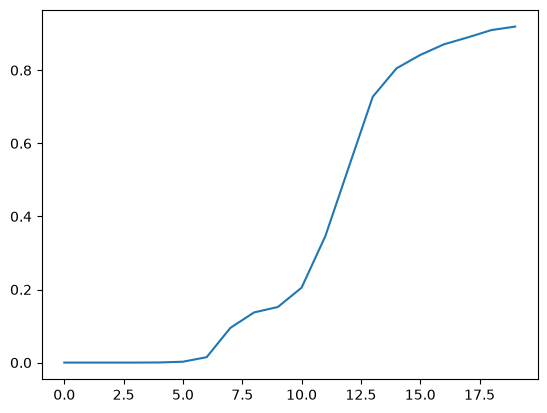

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(range(num_steps), preds.detach().numpy()[:,max_class])
plt.show()

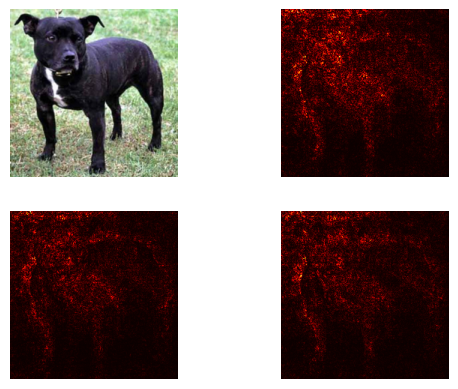

In [32]:
fig, axs = plt.subplots(2, 2)

axs[0, 0].set_axis_off()
axs[1, 0].set_axis_off()
axs[0, 1].set_axis_off()
axs[1, 1].set_axis_off()

norm_gradients = (gradients.abs() - gradients.abs().min()) / (gradients.abs().max() - gradients.abs().min())

axs[0, 0].imshow(input_tensor.permute(1,2,0))
axs[0, 1].imshow(norm_gradients.permute(1,2,0)[:,:,0]*255, cmap="hot")
axs[1, 0].imshow(norm_gradients.permute(1,2,0)[:,:,1]*255, cmap="hot")
axs[1, 1].imshow(norm_gradients.permute(1,2,0)[:,:,2]*255, cmap="hot")
plt.show()

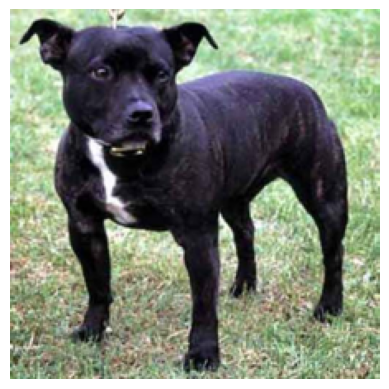

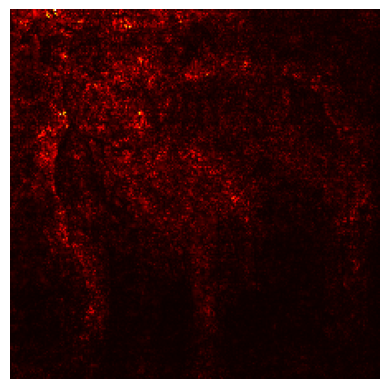

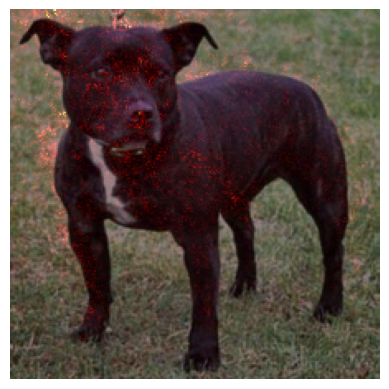

In [33]:
fig, ax = plt.subplots()
ax.set_axis_off()
ax.imshow(input_tensor.permute(1,2,0))
plt.show()

fig, ax = plt.subplots()
ax.imshow(norm_gradients.permute(1,2,0).sum(dim=2), cmap="hot", alpha=1)
ax.set_axis_off()
plt.show()

fig, ax = plt.subplots()
ax.imshow(input_tensor.permute(1,2,0))
ax.imshow(norm_gradients.permute(1,2,0).sum(dim=2), cmap="hot", alpha=0.5)
ax.set_axis_off()
plt.show()